# Loan Default Risk Analysis
## Notebook 05 — Final Load Preparation: KPIs, Risk Segmentation & Tableau-Ready Export

**Problem Statement:** Financial institutions face significant losses due to loan defaults and inefficient borrower screening. This project identifies the key financial and behavioral factors driving loan defaults and develops a data-driven risk segmentation framework to support more effective lending decisions and improved portfolio performance.

**Objective:** Compute portfolio-level KPIs, build a risk segmentation framework based on statistical findings from Notebooks 03–04, and export a Tableau-ready dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/loan_final_cleaned.csv')
df['gender'] = df['gender'].fillna('NA')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (15000, 34)


,id,year,loan_limit,gender,approv_in_adv,loan_type,loan_purpose,credit_worthiness,open_credit,business_or_commercial,...,credit_score,co-applicant_credit_type,age,submission_of_application,ltv,region,status,debt_to_income_ratio,ltv_risk_bucket,credit_score_bucket
0,49802,2019,conforming loan,female,no pre-approval,personal loan,debt consolidation,high creditworthy,no open credit,business use,...,679,cib,45-54,to_inst,84.420290,north,0,41.0,High,Good
1,171958,2019,conforming loan,NA,pre-approved,home loan,business purpose,high creditworthy,no open credit,personal use,...,853,exp,25-34,to_inst,88.246269,south,0,44.0,High,Excellent
2,148174,2019,conforming loan,NA,no pre-approval,home loan,debt consolidation,high creditworthy,no open credit,personal use,...,598,exp,65-74,to_inst,19.279661,south,0,41.0,Low,Poor
3,78500,2019,conforming loan,female,no pre-approval,home loan,debt consolidation,high creditworthy,no open credit,personal use,...,776,exp,65-74,to_inst,36.228814,north,0,32.0,Low,Excellent
4,64562,2019,conforming loan,female,no pre-approval,home loan,home purchase,high creditworthy,no open credit,personal use,...,653,cib,35-44,not_inst,81.921241,north,0,48.0,High,Good


---
## Dashboard 1 — Portfolio Exposure & Default Risk Overview

**Business Question:** *"How healthy is our current portfolio, and where is our risk concentrated?"*

**KPI Cards:** Total Loans, Default Rate, Total Loan Amount, High Risk %, Avg Interest Rate

**Charts:** Loan Distribution by Product, Interest Rate vs Default by Loan Purpose, Loan Amount Distribution, Loan Amount by Interest Rate

**Filters:** Loan Purpose, Region, Credit Score Bucket

### Dashboard 1 — KPI Card Metrics

In [ ]:
# ── Dashboard 1: KPI Cards ──
total_loans = len(df)
total_defaults = df['status'].sum()
default_rate = (total_defaults / total_loans) * 100
total_exposure = df['loan_amount'].sum()
ead = df[df['status'] == 1]['loan_amount'].sum()
high_risk_pct = (df['ltv'] > 80).sum() / total_loans * 100
avg_interest_rate = df['rate_of_interest'].mean()

print(f'Total Loans:        {total_loans:,}')
print(f'Default Rate:       {default_rate:.2f}%')
print(f'Total Loan Amt:     ₹{total_exposure:,.0f}')
print(f'High Risk %:        {high_risk_pct:.2f}%')
print(f'Avg Interest Rate:  {avg_interest_rate:.3f}%')
print(f'EAD:                ₹{ead:,.0f}')

### Dashboard 1 — Expected Loss (EL)

The #1 CFO metric combining probability, severity, and exposure.

In [ ]:
# ── Expected Loss ──
df['lgd'] = df['loan_amount'] - (df['property_value'] * (1 - df['ltv']/100) * 0.8)
df['expected_loss'] = df['status'] * df['lgd']
total_el = df['expected_loss'].sum()
el_rate = (total_el / total_exposure) * 100
print(f'Total Expected Loss: ₹{total_el:,.0f}')
print(f'EL Rate: {el_rate:.2f}% of portfolio')

### Dashboard 1 — Loan Distribution by Product

In [ ]:
# ── Loan Distribution by Product (Donut) ──
product_dist = df.groupby('loan_type')['loan_amount'].sum().sort_values(ascending=False)
print('=== Loan Distribution by Product ===')
for lt, amt in product_dist.items():
    print(f'  {lt:20s} → ₹{amt:,.0f}')

fig, ax = plt.subplots(figsize=(7, 7))
colors_prod = ['#E0A854', '#5fba7d', '#d65f5f']
wedges, texts, autotexts = ax.pie(product_dist.values, labels=product_dist.index,
    autopct='%1.1f%%', colors=colors_prod, startangle=90, pctdistance=0.75)
ax.add_artist(plt.Circle((0,0), 0.50, fc='white'))
ax.set_title('Loan Distribution by Product', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### Dashboard 1 — Interest Rate vs Default by Loan Purpose

In [ ]:
# ── Interest Rate vs Default by Loan Purpose (Scatter) ──
purpose_metrics = df.groupby('loan_purpose').agg(
    avg_rate=('rate_of_interest','mean'), default_rate=('status','mean')
).reset_index()
print('=== Interest Rate vs Default by Loan Purpose ===')
for _, r in purpose_metrics.iterrows():
    print(f'  {r["loan_purpose"]:25s} → Rate: {r["avg_rate"]:.3f}%, DR: {r["default_rate"]:.4f}')

fig, ax = plt.subplots(figsize=(8,5))
c = ['#d65f5f','#E0A854','#5fba7d','#6baed6']
for i,(_,r) in enumerate(purpose_metrics.iterrows()):
    ax.scatter(r['avg_rate'], r['default_rate'], s=200, c=c[i%4], zorder=5, edgecolors='white', lw=2)
    ax.annotate(r['loan_purpose'], (r['avg_rate'], r['default_rate']),
                textcoords='offset points', xytext=(10,8), fontsize=10, fontweight='bold')
ax.set_xlabel('Avg Interest Rate'); ax.set_ylabel('Default Rate')
ax.set_title('Interest Rate vs Default by Loan Purpose', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Dashboard 1 — Loan Amount Distribution

In [ ]:
# ── Loan Amount Distribution (Histogram) ──
fig, ax = plt.subplots(figsize=(10,4))
ax.hist(df['loan_amount'], bins=30, color='#5fba7d', edgecolor='white', alpha=0.9)
ax.set_xlabel('Loan Amount'); ax.set_ylabel('Count')
ax.set_title('Loan Amount Distribution', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### Dashboard 1 — Loan Amount by Interest Rate

In [ ]:
# ── Loan Amount by Interest Rate (by Loan Purpose) ──
fig, ax = plt.subplots(figsize=(10,5))
for purpose in df['loan_purpose'].unique():
    sub = df[df['loan_purpose']==purpose]
    binned = sub.groupby(pd.cut(sub['rate_of_interest'], bins=20))['loan_amount'].sum()
    ax.fill_between(range(len(binned)), binned.values, alpha=0.5, label=purpose)
ax.set_xlabel('Rate of Interest (bin)'); ax.set_ylabel('Loan Amount')
ax.set_title('Loan Amount by Interest Rate', fontsize=14, fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

---
## Dashboard 2 — Borrower Risk Drivers Analysis

**Business Question:** *"What borrower characteristics drive default, and how should we adjust underwriting?"*

**KPI Cards:** Average Income, Credit Score Gap, High Borrower Risk %, Borrower Income Gap

**Charts:** Default Rate by LTV, Default by Income, LTV × Credit Score Heatmap, Loan Volume vs Default Volume by Credit Score, Default Rate by Credit Score Bucket

**Filters:** Loan Type, Credit Score Bucket, Region, Approv In Adv, LTV Risk Bucket

### Dashboard 2 — KPI Card Metrics

In [ ]:
# ── Dashboard 2: KPI Cards ──
avg_income = df['income'].mean()

# Credit Score Gap: ratio of avg credit score (defaulters) to avg credit score (non-defaulters)
avg_cs_default = df[df['status']==1]['credit_score'].mean()
avg_cs_nodefault = df[df['status']==0]['credit_score'].mean()
credit_score_gap = avg_cs_default / avg_cs_nodefault

# Borrower Income Gap: ratio of avg income (defaulters) to avg income (all)
avg_income_default = df[df['status']==1]['income'].mean()
borrower_income_gap = avg_income_default / avg_income

print(f'Average Income:       {avg_income:,.0f}')
print(f'Credit Score Gap:     {credit_score_gap:.4f}')
print(f'High Borrower Risk %: {high_risk_pct:.2f}%')
print(f'Borrower Income Gap:  {borrower_income_gap:.4f}')

### Dashboard 2 — Default Rate by LTV

In [ ]:
# ── Default Rate by LTV (line chart per loan type) ──
df['ltv_bin'] = pd.cut(df['ltv'], bins=range(0, 100, 10))
fig, ax = plt.subplots(figsize=(10,5))
for lt in df['loan_type'].unique():
    sub = df[df['loan_type']==lt]
    dr = sub.groupby('ltv_bin', observed=True)['status'].mean() * 100
    ax.plot(range(len(dr)), dr.values, marker='o', label=lt, linewidth=2)
ax.set_xlabel('LTV (bin)'); ax.set_ylabel('Default Rate %')
ax.set_title('Default Rate by LTV', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Dashboard 2 — Default by Income

In [ ]:
# ── Default Rate by Income (line chart per loan type) ──
df['income_bin'] = pd.cut(df['income'], bins=7)
fig, ax = plt.subplots(figsize=(10,5))
for lt in df['loan_type'].unique():
    sub = df[df['loan_type']==lt]
    dr = sub.groupby('income_bin', observed=True)['status'].mean() * 100
    ax.plot(range(len(dr)), dr.values, marker='o', label=lt, linewidth=2)
ax.set_xlabel('Income (bin)'); ax.set_ylabel('Default Rate %')
ax.set_title('Default by Income', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Dashboard 2 — LTV × Credit Score — Default Rate Heatmap

In [ ]:
# ── LTV × Credit Score Default Rate Heatmap ──
hm = df.groupby(['ltv_risk_bucket','credit_score_bucket'])['status'].mean() * 100
hm = hm.unstack(fill_value=0)
ltv_order = ['Moderate','Low','High','Very High']
cs_order = [c for c in ['Excellent','Fair','Good','Poor','Very Good'] if c in hm.columns]
hm = hm.reindex(index=[x for x in ltv_order if x in hm.index], columns=cs_order)
fig, ax = plt.subplots(figsize=(10,5))
sns.heatmap(hm, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('LTV × Credit Score — Default Rate Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### Dashboard 2 — Loan Volume vs Default Volume by Credit Score

In [ ]:
# ── Loan Volume vs Default Volume by Credit Score ──
cs_vol = df.groupby('credit_score_bucket').agg(
    loan_count=('status','count'), default_count=('status','sum')
)
cs_order2 = ['Excellent','Poor','Good','Fair','Very Good']
cs_vol = cs_vol.reindex([x for x in cs_order2 if x in cs_vol.index])
print('=== Loan Volume vs Default Volume by Credit Score ===')
print(cs_vol)

fig, ax = plt.subplots(figsize=(8,5))
x = range(len(cs_vol))
ax.bar(x, cs_vol['loan_count'], color='#5fba7d', label='Total Loans')
ax.bar(x, cs_vol['default_count'], color='#d65f5f', label='Defaults')
ax.set_xticks(x); ax.set_xticklabels(cs_vol.index, rotation=45)
ax.set_title('Loan Volume vs Default Volume by Credit Score', fontsize=14, fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

### Dashboard 2 — Default Rate by Credit Score Bucket

In [ ]:
# ── Default Rate by Credit Score Bucket ──
dr_cs = df.groupby('credit_score_bucket')['status'].mean() * 100
dr_cs = dr_cs.reindex([x for x in ['Excellent','Very Good','Good','Fair','Poor'] if x in dr_cs.index])
print('=== Default Rate by Credit Score Bucket ===')
for b, r in dr_cs.items(): print(f'  {b:15s} → {r:.2f}%')

fig, ax = plt.subplots(figsize=(8,5))
colors_cs = ['#5fba7d','#6baed6','#E0A854','#d65f5f','#a50026']
ax.bar(dr_cs.index, dr_cs.values, color=colors_cs[:len(dr_cs)])
ax.set_ylabel('Default Rate %')
ax.set_title('Default Rate by Credit Score Bucket', fontsize=14, fontweight='bold')
for i,(b,v) in enumerate(dr_cs.items()): ax.text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

---
## Dashboard 3 — Product & Geographic Risk Trends

**Business Question:** *"Which products and regions are bleeding money, and where should we restrict lending?"*

**KPI Cards:** Top Loan Purpose, Average Term, Highest-Loss Region, Most Risky Loan Type, Worst Region–Product Combo

**Charts:** Loss by Region, Risk vs Pricing by Loan Type, Region-LoanType Heatmap, Loss Share, Average DTI by Loan Type, Default Rate by Loan Type

**Filters:** Region, Loan Type, Loan Limit, Approv In Adv

### Dashboard 3 — KPI Card Metrics

In [ ]:
# ── Dashboard 3: KPI Cards ──
defaults_d3 = df[df['status'] == 1]

# Top Loan Purpose (by defaulted amount)
loss_by_purpose = defaults_d3.groupby('loan_purpose')['loan_amount'].sum()
top_purpose = loss_by_purpose.idxmax()

# Average Term
avg_term = df['term'].mean()

# Highest-Loss Region
loss_by_region = defaults_d3.groupby('region')['loan_amount'].sum().sort_values(ascending=False)

# Most Risky Loan Type
dr_by_type = df.groupby('loan_type')['status'].mean()
most_risky = dr_by_type.idxmax()

# Worst Region-Product Combo
combo = defaults_d3.groupby(['region','loan_type'])['loan_amount'].sum().sort_values(ascending=False)

print(f'Top Loan Purpose:    {top_purpose}')
print(f'Average Term:        {avg_term:.1f}')
print(f'Highest-Loss Region: {loss_by_region.index[0]} ₹{loss_by_region.iloc[0]:,.0f}, {loss_by_region.index[1]} ₹{loss_by_region.iloc[1]:,.0f}')
print(f'Most Risky Type:     {most_risky} {dr_by_type.max():.2%}')
print(f'Worst Combo:         {combo.index[0][0]} - {combo.index[0][1]} ₹{combo.iloc[0]:,.0f}')

### Dashboard 3 — Loss by Region

In [ ]:
# ── Loss by Region ──
lr = loss_by_region.sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10,4))
ax.barh(lr.index, lr.values, color=['#d65f5f' if r==lr.idxmax() else '#E0A854' for r in lr.index])
ax.set_xlabel('Defaulted Loan Amount')
ax.set_title('Loss by Region', fontsize=14, fontweight='bold')
for i,(r,v) in enumerate(lr.items()): ax.text(v+5e6, i, f'₹{v:,.0f}', va='center', fontweight='bold')
plt.tight_layout(); plt.show()

### Dashboard 3 — Risk vs Pricing by Loan Type

In [ ]:
# ── Risk vs Pricing by Loan Type ──
rp = df.groupby('loan_type').agg(avg_rate=('rate_of_interest','mean'), dr=('status','mean')).reset_index()
fig, ax = plt.subplots(figsize=(8,5))
c = ['#d65f5f','#5fba7d','#E0A854']
for i,(_,r) in enumerate(rp.iterrows()):
    ax.scatter(r['avg_rate'], r['dr'], s=200, c=c[i%3], zorder=5, edgecolors='white', lw=2)
    ax.annotate(r['loan_type'], (r['avg_rate'], r['dr']), textcoords='offset points', xytext=(12,5), fontsize=11, fontweight='bold')
ax.set_xlabel('Avg Interest Rate'); ax.set_ylabel('Default Rate')
ax.set_title('Risk vs Pricing by Loan Type', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Dashboard 3 — Region × Loan Type Heatmap

In [ ]:
# ── Region × Loan Type Heatmap (Defaulted Amount) ──
hm3 = pd.crosstab(defaults_d3['region'], defaults_d3['loan_type'], values=defaults_d3['loan_amount'], aggfunc='sum')
print(hm3.to_string())
fig, ax = plt.subplots(figsize=(10,5))
sns.heatmap(hm3, annot=True, fmt=',.0f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Region × Loan Type — Defaulted Amount', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### Dashboard 3 — Loss Share by Loan Purpose

In [ ]:
# ── Loss Share (Donut) ──
ls = (loss_by_purpose / loss_by_purpose.sum() * 100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7,7))
w,t,a = ax.pie(ls.values, labels=ls.index, autopct='%1.2f%%', colors=['#d65f5f','#E0A854','#5fba7d','#6baed6'], startangle=90, pctdistance=0.75)
ax.add_artist(plt.Circle((0,0), 0.50, fc='white'))
ax.set_title('Loss Share by Loan Purpose', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### Dashboard 3 — Average DTI by Loan Type

In [ ]:
# ── Average DTI by Loan Type ──
dti = df.groupby('loan_type')['debt_to_income_ratio'].mean().sort_values()
fig, ax = plt.subplots(figsize=(8,4))
ax.scatter(dti.values, dti.index, s=120, c='#5fba7d', zorder=5)
ax.set_xlabel('Avg. Debt To Income Ratio')
ax.set_title('Average DTI by Loan Type', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for lt, v in dti.items(): ax.annotate(f'{v:.1f}', (v, lt), textcoords='offset points', xytext=(10,0), fontweight='bold')
plt.tight_layout(); plt.show()

### Dashboard 3 — Default Rate by Loan Type

In [ ]:
# ── Default Rate by Loan Type ──
dr_lt = df.groupby('loan_type')['status'].mean().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8,4))
ax.barh(dr_lt.index, dr_lt.values, color=['#E0A854' if v<dr_lt.max() else '#d65f5f' for v in dr_lt])
ax.set_xlabel('Default Rate')
ax.set_title('Default Rate by Loan Type', fontsize=14, fontweight='bold')
for i,(lt,v) in enumerate(dr_lt.items()): ax.text(v+0.005, i, f'{v:.4f}', va='center', fontweight='bold')
plt.tight_layout(); plt.show()

---
## Section 2: Risk Segmentation Framework

Based on statistical findings from Notebooks 03–04:
- **Credit score** excluded (p=0.735, r=-0.0028) — not a valid predictor
- **LTV** is the strongest numerical predictor (r=0.0976, logistic coeff=0.2239)
- **DTI** is the second strongest (r=0.0929, logistic coeff=0.1952)
- **Product features** dominate categorical risk — neg_ammortization (χ²=363.1), lump_sum_payment (χ²=498.5)

**Risk Tiers:** Low (≤2), Medium (3–5), High (6–8), Very High (>8)

In [13]:
def compute_risk_score(row, median_income):
    score = 0
    if row['debt_to_income_ratio'] > 50: score += 4
    elif row['debt_to_income_ratio'] > 35: score += 2
    ltv_bucket = row.get('ltv_risk_bucket', '')
    if ltv_bucket == 'Very High': score += 3
    elif ltv_bucket == 'High': score += 2
    elif ltv_bucket == 'Moderate': score += 1
    if row.get('neg_ammortization', 'no') == 'yes': score += 3
    if row.get('lump_sum_payment', 'no') == 'yes': score -= 2
    if row['income'] < median_income: score += 1
    return max(score, 0)

median_income = df['income'].median()
df['risk_score'] = df.apply(lambda row: compute_risk_score(row, median_income), axis=1)

def assign_risk_tier(score):
    if score <= 2: return 'Low'
    elif score <= 5: return 'Medium'
    elif score <= 8: return 'High'
    else: return 'Very High'

df['risk_tier'] = df['risk_score'].apply(assign_risk_tier)
print('Risk Tier Distribution:')
print(df['risk_tier'].value_counts())

Risk Tier Distribution:
risk_tier
Medium       8431
Low          4170
High         2246
Very High     153
Name: count, dtype: int64


### KPI 14 — Concentration Risk — % of Portfolio in High/Very High Tiers
**Definition:** Percentage of portfolio (by count and exposure) sitting in High and Very High risk tiers.
**Formula:** `(Loans in High + Very High) / Total Loans × 100`

**Why it matters:** This shows how much of the portfolio is sitting on a **time bomb**. Key implications:
- **Regulatory threshold:** Most lenders cap high-risk exposure at 15–20% of the portfolio
- **Capital reserves:** Higher concentration = more capital the bank must hold in reserve (reducing profitability)
- **Systemic risk:** A concentrated portfolio amplifies losses during economic downturns

**Decision Support:** If >25% of portfolio is High/Very High, immediate portfolio rebalancing is needed. The new approval strategy should restrict inflow into these tiers.

In [14]:
high_risk_concentration = df[df['risk_tier'].isin(['High', 'Very High'])].shape[0] / len(df) * 100
exposure_concentration = df[df['risk_tier'].isin(['High', 'Very High'])]['loan_amount'].sum() / df['loan_amount'].sum() * 100

print(f'High-risk loan count: {high_risk_concentration:.1f}%')
print(f'High-risk exposure: {exposure_concentration:.1f}%')
print(f'\nBenchmark: Regulatory cap at 15-20%. {"EXCEEDS — immediate rebalancing needed." if high_risk_concentration > 25 else "Within acceptable range."}')

High-risk loan count: 16.0%
High-risk exposure: 13.8%

Benchmark: Regulatory cap at 15-20%. Within acceptable range.


### Validate Risk Segmentation — Default Rate by Risk Tier

In [15]:
risk_val = df.groupby('risk_tier').agg(
    total_loans=('status','count'), defaults=('status','sum'),
    total_exposure=('loan_amount','sum'), avg_score=('risk_score','mean')
).assign(default_rate=lambda x: (x['defaults']/x['total_loans']*100).round(2))
risk_val = risk_val.reindex(['Low','Medium','High','Very High'])
risk_val

,total_loans,defaults,total_exposure,avg_score,default_rate
risk_tier,,,,,
Low,4170,537,1468515000,1.216547,12.88
Medium,8431,2097,2810741500,3.796703,24.87
High,2246,831,648539000,6.650045,37.00
Very High,153,93,38344500,9.522876,60.78


### Risk Tier Visualisation

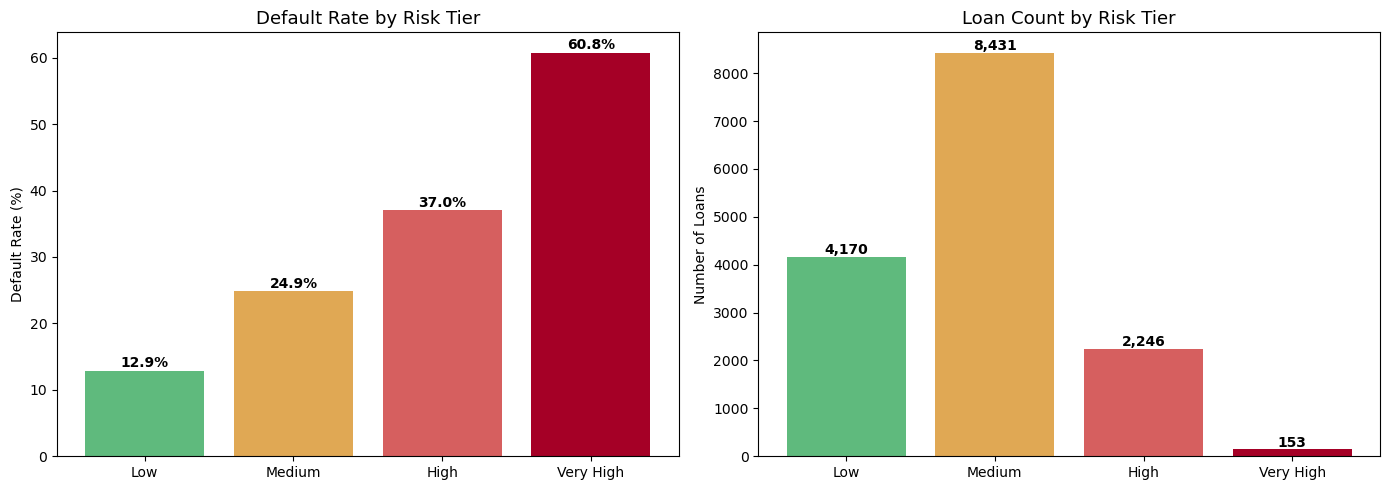

In [16]:
tier_order = ['Low', 'Medium', 'High', 'Very High']
colors = ['#5fba7d', '#E0A854', '#d65f5f', '#a50026']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rv = risk_val.reset_index()
rv['risk_tier'] = pd.Categorical(rv['risk_tier'], categories=tier_order, ordered=True)
rv = rv.sort_values('risk_tier')
axes[0].bar(rv['risk_tier'], rv['default_rate'], color=colors)
axes[0].set_title('Default Rate by Risk Tier', fontsize=13)
axes[0].set_ylabel('Default Rate (%)')
for i, (_, row) in enumerate(rv.iterrows()):
    axes[0].text(i, row['default_rate']+0.5, f"{row['default_rate']:.1f}%", ha='center', fontweight='bold')
axes[1].bar(rv['risk_tier'], rv['total_loans'], color=colors)
axes[1].set_title('Loan Count by Risk Tier', fontsize=13)
axes[1].set_ylabel('Number of Loans')
for i, (_, row) in enumerate(rv.iterrows()):
    axes[1].text(i, row['total_loans']+50, f"{row['total_loans']:,}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Final Tableau-Ready Export

In [ ]:
# ── Pre-compute helper column + export ──
df['defaulted_loan_amount'] = df['loan_amount'] * df['status']
df_export = df.drop(columns=['lgd','expected_loss','recoverable_value','would_approve','lending_action','ltv_bin','income_bin'], errors='ignore')
print(f'Final shape: {df_export.shape}')
df_export.to_csv('../data/processed/loan_tableau_ready.csv', index=False)
print(f'Exported to: ../data/processed/loan_tableau_ready.csv')

---
## KPI Framework Summary

### Dashboard 1 — Portfolio Exposure & Default Risk Overview
| # | KPI | Formula |
|---|-----|---------|
| 1 | Total Loans | COUNT(*) |
| 2 | Default Rate | Defaults / Total × 100 |
| 3 | Total Loan Amount | SUM(loan_amount) |
| 4 | High Risk % | COUNT(LTV>80) / Total × 100 |
| 5 | Avg Interest Rate | AVG(rate_of_interest) |
| 6 | Expected Loss | Default Rate × LGD × EAD |

### Dashboard 2 — Borrower Risk Drivers Analysis
| # | KPI | Formula |
|---|-----|---------|
| 7 | Average Income | AVG(income) |
| 8 | Credit Score Gap | AVG(credit_score, defaulters) / AVG(credit_score, non-defaulters) |
| 9 | High Borrower Risk % | COUNT(LTV>80) / Total × 100 |
| 10 | Borrower Income Gap | AVG(income, defaulters) / AVG(income, all) |

### Dashboard 3 — Product & Geographic Risk Trends
| # | KPI | Formula |
|---|-----|---------|
| 11 | Top Loan Purpose | MAX(SUM(defaulted_amount) BY purpose) |
| 12 | Average Term | AVG(term) |
| 13 | Highest-Loss Region | MAX(SUM(defaulted_amount) BY region) |
| 14 | Most Risky Loan Type | MAX(Default Rate BY loan_type) |
| 15 | Worst Region–Product Combo | MAX(SUM(defaulted_amount) BY region, loan_type) |
| 16 | Loss Share by Purpose | defaulted_per_purpose / total_defaulted × 100 |